Data Cleaning

In [ ]:
import pandas as pd

df = pd.read_csv('/content/bank-full.csv', sep=';')
df.head()
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [ ]:
selected_cols = ['age', 'job', 'balance', 'housing', 'loan', 'duration', 'campaign', 'poutcome', 'y']
df = df[selected_cols]
df.head()

,age,job,balance,housing,loan,duration,campaign,poutcome,y
0,58,management,2143,yes,no,261,1,unknown,no
1,44,technician,29,yes,no,151,1,unknown,no
2,33,entrepreneur,2,yes,yes,76,1,unknown,no
3,47,blue-collar,1506,yes,no,92,1,unknown,no
4,33,unknown,1,no,no,198,1,unknown,no


In [ ]:
print(df['y'].unique())
print(df['y'].value_counts(dropna=False))

['no' 'yes']
y
no     39922
yes     5289
Name: count, dtype: int64


In [ ]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

Shape: (45211, 9)

Data types:
age          int64
job         object
balance      int64
housing     object
loan        object
duration     int64
campaign     int64
poutcome    object
y           object
dtype: object

Missing values:
age         0
job         0
balance     0
housing     0
loan        0
duration    0
campaign    0
poutcome    0
y           0
dtype: int64

Duplicates: 4


In [ ]:
df = df.drop_duplicates()
print("New shape:", df.shape)

New shape: (45207, 9)


In [ ]:
for col in ['job', 'housing', 'loan', 'poutcome', 'y']:
    print(f"\n{col}:")
    print(df[col].value_counts())


job:
job
blue-collar      9732
management       9455
technician       7596
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

housing:
housing
yes    25129
no     20078
Name: count, dtype: int64

loan:
loan
no     37963
yes     7244
Name: count, dtype: int64

poutcome:
poutcome
unknown    36955
failure     4901
other       1840
success     1511
Name: count, dtype: int64

y:
y
no     39918
yes     5289
Name: count, dtype: int64


In [ ]:
# Convert housing, loan, and y from yes/no to 1/0.
binary_map = {'yes': 1, 'no': 0}

df['housing'] = df['housing'].map(binary_map)
df['loan'] = df['loan'].map(binary_map)
df['y'] = df['y'].map(binary_map)

In [ ]:
df_encoded = pd.get_dummies(df, columns=['job', 'poutcome'], drop_first=True)
df_encoded.head()

,age,balance,housing,loan,duration,campaign,y,job_blue-collar,job_entrepreneur,job_housemaid,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,1,0,261,1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,44,29,1,0,151,1,0,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,33,2,1,1,76,1,0,False,True,False,...,False,False,False,False,False,False,False,False,False,True
3,47,1506,1,0,92,1,0,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4,33,1,0,0,198,1,0,False,False,False,...,False,False,False,False,False,False,True,False,False,True


In [ ]:
df_encoded.to_csv('/content/bank_cleaned.csv', index=False)
print("Saved cleaned dataset.")

Saved cleaned dataset.


In [ ]:
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45207, 20)
y shape: (45207,)


In [ ]:
X.to_csv('/content/X_bank.csv', index=False)
y.to_csv('/content/y_bank.csv', index=False)

Simple EDA

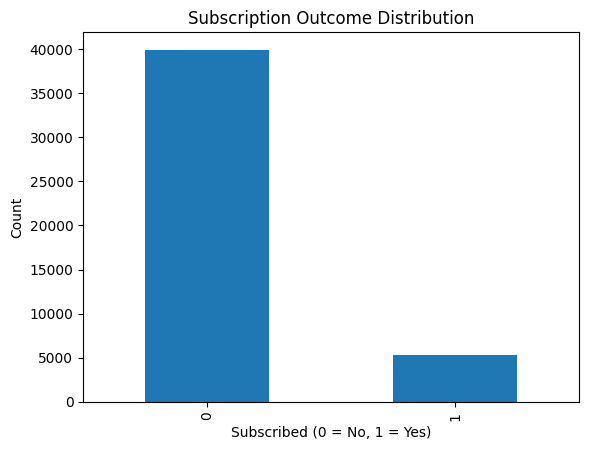

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('/content/bank_cleaned.csv')
df.columns

df['y'].value_counts().plot(kind='bar')
plt.title('Subscription Outcome Distribution')
plt.xlabel('Subscribed (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.savefig('/content/subscription_outcome.png', dpi=300, bbox_inches='tight')
plt.show()

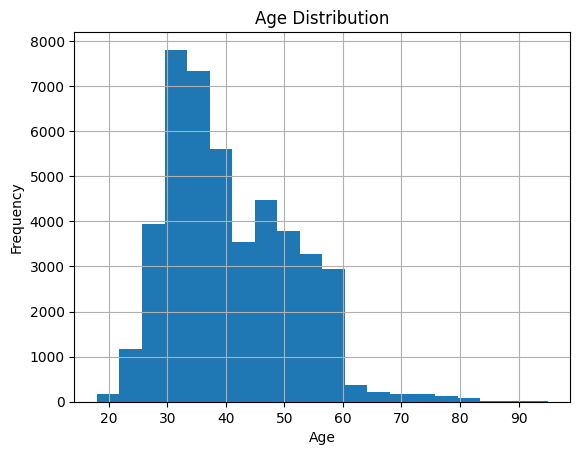

In [ ]:
df['age'].hist(bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('/content/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

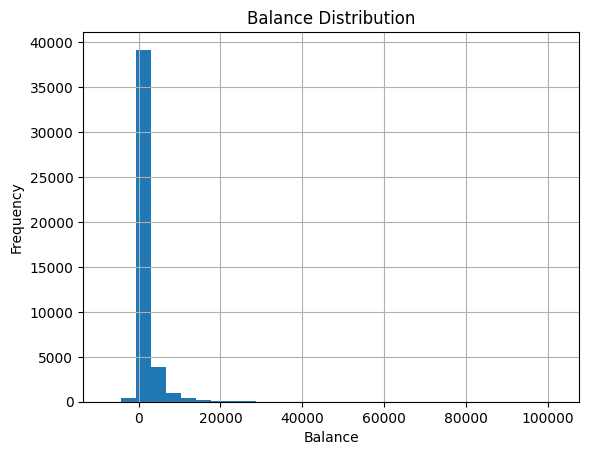

In [ ]:
df['balance'].hist(bins=30)
plt.title('Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.savefig('/content/balance_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Data before binary encode
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/bank-full.csv', sep=';')

selected_cols = ['age', 'job', 'balance', 'housing', 'loan', 'duration', 'campaign', 'poutcome', 'y']
df = df[selected_cols].copy()

for col in ['housing', 'loan', 'y', 'job', 'poutcome']:
    df[col] = df[col].astype(str).str.strip().str.lower()

binary_map = {'yes': 1, 'no': 0}
df['housing'] = df['housing'].map(binary_map)
df['loan'] = df['loan'].map(binary_map)
df['y'] = df['y'].map(binary_map)

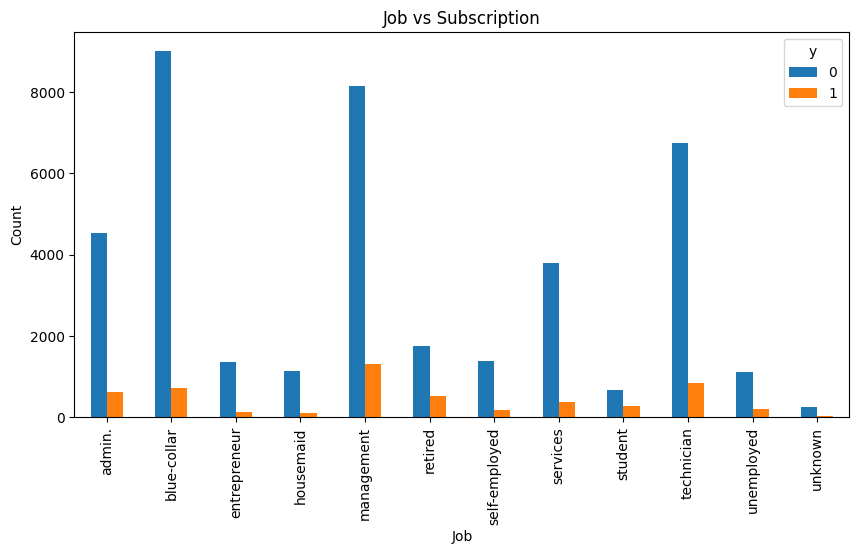

In [ ]:
pd.crosstab(df['job'], df['y']).plot(kind='bar', figsize=(10,5))
plt.title('Job vs Subscription')
plt.xlabel('Job')
plt.ylabel('Count')
plt.savefig('/content/job_vs_subscription.png', dpi=300, bbox_inches='tight')
plt.show()

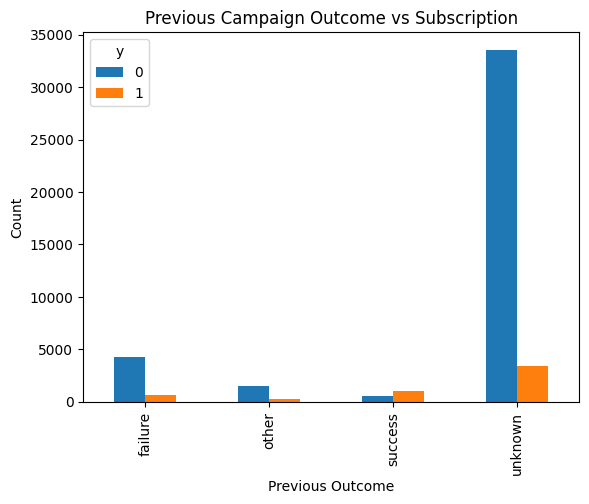

In [ ]:
pd.crosstab(df['poutcome'], df['y']).plot(kind='bar')
plt.title('Previous Campaign Outcome vs Subscription')
plt.xlabel('Previous Outcome')
plt.ylabel('Count')
plt.savefig('/content/poutcome_vs_subscription.png', dpi=300, bbox_inches='tight')
plt.show()

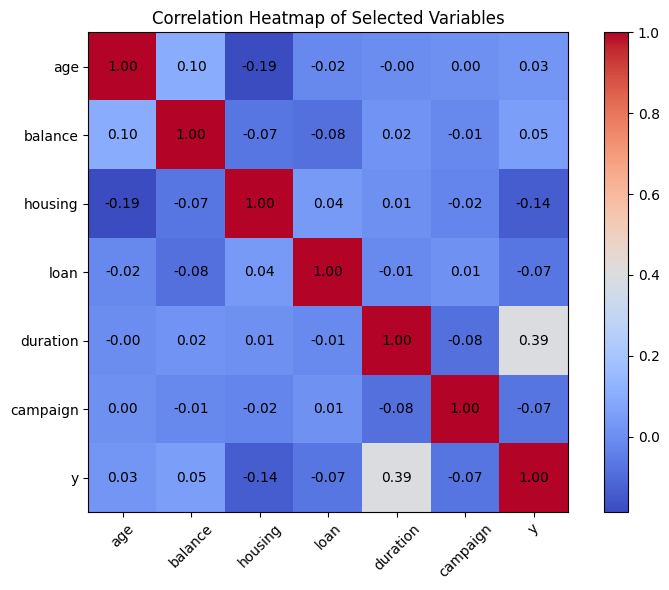

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Load original dataset
df = pd.read_csv('/content/bank-full.csv', sep=';')

# Keep selected columns
df = df[['age', 'job', 'balance', 'housing', 'loan', 'duration', 'campaign', 'poutcome', 'y']].copy()

# Clean text columns
for col in ['housing', 'loan', 'y', 'job', 'poutcome']:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Encode binary columns
binary_map = {'yes': 1, 'no': 0}
df['housing'] = df['housing'].map(binary_map)
df['loan'] = df['loan'].map(binary_map)
df['y'] = df['y'].map(binary_map)

# Correlation matrix using numeric + encoded variables
corr_cols = ['age', 'balance', 'housing', 'loan', 'duration', 'campaign', 'y']
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation Heatmap of Selected Variables')

# Add correlation values inside cells
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.tight_layout()
plt.savefig('/content/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# Summary statistics
df.describe()

# Target class percentage
df['y'].value_counts(normalize=True) * 100

# Subscription rate by job
pd.crosstab(df['job'], df['y'], normalize='index') * 100

# Subscription rate by previous campaign outcome
pd.crosstab(df['poutcome'], df['y'], normalize='index') * 100

y,0,1
poutcome,,
failure,87.390329,12.609671
other,83.315217,16.684783
success,35.274653,64.725347
unknown,90.838497,9.161503


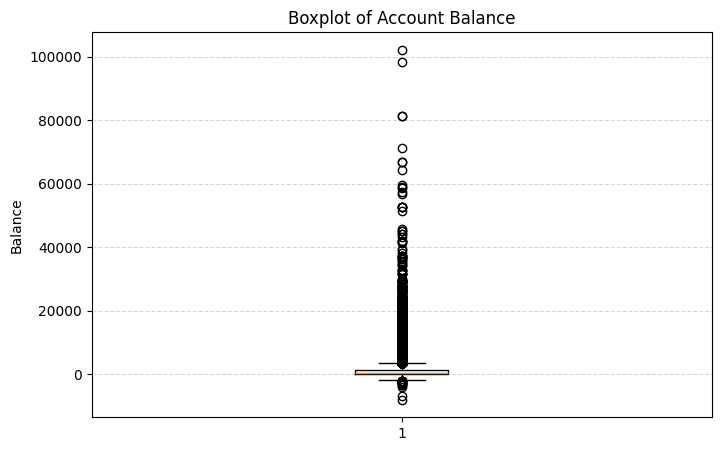

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load original dataset
df = pd.read_csv('/content/bank-full.csv', sep=';')

# Keep selected columns
df = df[['age', 'job', 'balance', 'housing', 'loan', 'duration', 'campaign', 'poutcome', 'y']].copy()

# Boxplot for outlier detection on balance
plt.figure(figsize=(8,5))
plt.boxplot(df['balance'].dropna(), vert=True)
plt.title('Boxplot of Account Balance')
plt.ylabel('Balance')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.savefig('/content/balance_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()